# Lorenz-63 System

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict

In [ ]:
def lorenz_system(state, sigma=10.0, rho=28.0, beta=8/3):
    x, y, z = state
    
    dx_dt = sigma * (y - x)
    dy_dt = x * (rho - z) - y
    dz_dt = x * y - beta * z
    
    return np.array([dx_dt, dy_dt, dz_dt])

In [ ]:
def rk4_step(state, dt):
    k1 = lorenz_system(state)
    k2 = lorenz_system(state + (dt / 2) * k1)
    k3 = lorenz_system(state + (dt / 2) * k2)
    k4 = lorenz_system(state + dt * k3)
    
    return state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

In [ ]:
dt = 2.5e-2
total_steps = int(4e6)

In [ ]:
current_state = np.array([1.0, 1.0, 1.0])
trajectory = []

In [ ]:
for i in range(total_steps):
    trajectory.append(current_state)
    current_state = rk4_step(current_state, dt)

# Convert to a numpy array for easy handling
trajectory = np.array(trajectory)

print(f"Generated data shape: {trajectory.shape}")

In [ ]:
trajectory[:5,:]

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.plot(trajectory[:5000, 0], trajectory[:5000, 1], color='blue', lw=0.5)
ax1.set_xlabel('X (Convection rate)')
ax1.set_ylabel('Y (Horizontal Temp)')
ax1.set_title('XY Plane')


ax2.plot(trajectory[:5000, 0], trajectory[:5000, 2], color='red', lw=0.5)
ax2.set_xlabel('X')
ax2.set_ylabel('Z')
ax2.set_title('XZ Plane')


ax3.plot(trajectory[:5000, 1], trajectory[:5000, 2], color='green', lw=0.5)
ax3.set_xlabel('Y')
ax3.set_ylabel('Z ')
ax3.set_title('YZ Plane')

plt.tight_layout()
plt.show()

In [ ]:
def create_joint_windows(trajectory, n=2):
    total_steps = len(trajectory)
    num_possible_windows = total_steps - (n - 1)
    windows = []
    for i in range(num_possible_windows):
        window_segment = trajectory[i : i + n]
        flat_vector = window_segment.flatten()
        windows.append(flat_vector)

    return np.array(windows)

In [ ]:
time_windows = create_joint_windows(trajectory)
print(f"Time window data shape: {time_windows.shape}")

In [ ]:
print(time_windows[:5,:])

In [ ]:
train_dataset = time_windows[:int(1e6),:]

In [ ]:
train_mean = np.mean(train_dataset, axis=0)
train_std = np.std(train_dataset, axis=0)

epsilon = 1e-8

normalized_train_dataset = (train_dataset - train_mean) / (train_std + epsilon)

In [ ]:
print(f'Number of time windows (samples) in the Training Dataset = {len(train_dataset)}')

In [ ]:
class customDataset(Dataset):
    def __init__(self,x):
        self.features = torch.tensor(x,dtype = torch.float32)
    
    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self,index):
        return self.features[index,:]

In [ ]:
train_dataset = customDataset(normalized_train_dataset)
train_dataloader = DataLoader(normalized_train_dataset,batch_size = 500, shuffle=True)

In [ ]:
class ContinuousNADE(nn.Module):
    def __init__(self,input_dim = 6, hidden_dim = 1000):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.W = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.01)
        self.c = nn.Parameter(torch.zeros(hidden_dim))

        self.V_mu = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_mu = nn.Parameter(torch.zeros(input_dim))

        self.V_log_sigma = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_log_sigma = nn.Parameter(torch.zeros(input_dim))

    def forward(self,x):
        batch_size = x.shape[0]

        mu_outputs = torch.zeros_like(x)
        log_sigma_outputs = torch.zeros_like(x)

        a_i = self.c.repeat(batch_size,1)

        for i in range(self.input_dim):
            h_i = torch.relu(a_i)
            mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
            log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]
            log_sigma_i = torch.clamp(log_sigma_i, min=-5, max=2)
            mu_outputs[:, i] = mu_i
            log_sigma_outputs[:, i] = log_sigma_i

            if i < self.input_dim - 1:
                v_i = x[:, i].unsqueeze(1)
                W_i = self.W[:, i].unsqueeze(0)
                a_i = a_i + v_i * W_i

        return mu_outputs, log_sigma_outputs

    def sample(self):
        generated_sequence = torch.zeros(self.input_dim)
        a_i = self.c.clone()

        with torch.no_grad():
            for i in range(self.input_dim):
                h_i = torch.relu(a_i)
                mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
                log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]

                sigma_i = torch.exp(log_sigma_i)
                sampled_value = mu_i + sigma_i * torch.randn(1, device=mu_i.device)
                generated_sequence[i] = sampled_value
                if i < self.input_dim - 1:
                    a_i = a_i + self.W[:, i] * sampled_value

        return generated_sequence

In [ ]:
def gaussian_nll_loss(mu, log_sigma, target):

    variance = torch.exp(log_sigma) ** 2
    loss = 0.5 * ((target - mu) ** 2 / variance) + log_sigma + 0.5 * np.log(2 * np.pi)
    # Sum across the 6 dimensions, then get the mean for the batch
    return loss.sum(dim=1).mean()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ContinuousNADE().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001) 
train_loss_history = []
epochs = 50

for epoch in range(epochs):
    train_loss = 0.0
    model.train()
    
    for batch in train_dataloader:
        batch = batch.float().to(device)
        
        optimizer.zero_grad()
        mu_outputs, log_sigma_outputs = model(batch)
        loss = gaussian_nll_loss(mu_outputs, log_sigma_outputs, batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_loss = train_loss / len(train_dataloader)
    train_loss_history.append(avg_loss)
    if (epoch+1)%5 ==0:
        print(f'Epoch {epoch+1}/{epochs} | Avg Train Loss: {avg_loss:.4f}')

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(range(epochs),train_loss_history)
plt.xlabel('Epochs')
plt.ylabel('Gausian NLL (Loss per Datapoint)')
plt.title('Training Loss')
plt.grid(True)

In [ ]:
available_ground_truth = time_windows[int(1e6),:]
print(f'Avaible ground truth at last time step {available_ground_truth}')

In [ ]:
generate_samples = int(1e6)
time_window_samples = []
with torch.no_grad():
    for i in range(generate_samples):
        time_window_samples.append(model.sample())

        current_count = i + 1
        if current_count % 100000 == 0:
            print(current_count, "/", generate_samples, "have been generated")

In [ ]:
candidates = torch.stack(time_window_samples).to(device)
mu_tensor = torch.tensor(train_mean, device=candidates.device)
std_tensor = torch.tensor(train_std, device=candidates.device)
unnormalized_candidates = (candidates * std_tensor) + mu_tensor
candidate_tails = unnormalized_candidates[:, :3]
candidate_heads = unnormalized_candidates[:, 3:]

In [ ]:
forecast_horizon = int(1e5)
forecasted_trajectory = []
current_state = torch.tensor(available_ground_truth[3:], dtype=torch.float32).to(device)

In [ ]:
for i in range(forecast_horizon):
    distances = torch.norm(candidate_tails - current_state, dim=1)
    best_index = torch.argmin(distances)
    winning_forecast = candidate_heads[best_index]
    forecasted_trajectory.append(winning_forecast.cpu().numpy())
    current_state = winning_forecast

In [ ]:
forecasted_trajectory = np.array(forecasted_trajectory)
print(f"Forecasting complete! Shape: {forecasted_trajectory.shape}")

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.plot(forecasted_trajectory[:, 0], forecasted_trajectory[:, 1], color='blue', lw=0.5)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_title('XY Plane')

ax2.plot(forecasted_trajectory[:, 0], forecasted_trajectory[:, 2], color='red', lw=0.5)
ax2.set_xlabel('X')
ax2.set_ylabel('Z')
ax2.set_title('XZ Plane')

ax3.plot(forecasted_trajectory[:, 1], forecasted_trajectory[:, 2], color='green', lw=0.5)
ax3.set_xlabel('Y')
ax3.set_ylabel('Z ')
ax3.set_title('YZ Plane')

plt.tight_layout()
plt.show()

In [ ]:
start_idx = 1000000 
end_idx = 4000000
num_samples = 500

#Creating 500 base points equally spaced (every 6000 steps)
base_points = np.linspace(start_idx, end_idx - 1000, num_samples).astype(int)
random_offsets = np.random.randint(0, 1000, size=num_samples)
test_start_indices = base_points + random_offsets
print(f"First 5 indices: {test_start_indices[:5]}")

In [ ]:
all_preds = []
all_ground_truth = []

In [ ]:
mu_tensor = torch.tensor(train_mean, device=device)
std_tensor = torch.tensor(train_std, device=device)
for idx in test_start_indices:
    if idx + 400 > len(time_windows):
        continue
    current_state = torch.tensor(time_windows[idx, :3], device=device, dtype=torch.float32)
    truth = time_windows[idx : idx+400, 3:]
    all_ground_truth.append(truth)
    forecast = []

    for step in range(400):
        with torch.no_grad():
            distances = torch.norm(candidate_tails - current_state, dim=1)
            best_index = torch.argmin(distances)
            winning_forecast = candidate_heads[best_index]
        forecast.append(winning_forecast.cpu().numpy())
        current_state = winning_forecast
    all_preds.append(np.array(forecast))

In [ ]:
all_preds = np.array(all_preds)
all_ground_truth = np.array(all_ground_truth)
mae_per_step = np.mean(np.abs(all_preds - all_ground_truth), axis=0)   #400x3

In [ ]:
time_axis = np.linspace(0, 10, 400) 
plt.figure(figsize=(10, 6))

plt.plot(time_axis, mae_per_step[:, 0])

plt.xlabel('Time units ($t$)')
plt.ylabel('Mean Absolute Error (x)')
plt.title('MAE vs Time Units')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
time_axis = np.linspace(0, 10, 400) 
plt.figure(figsize=(10, 6))

plt.plot(time_axis, mae_per_step[:, 1])

plt.xlabel('Time units ($t$)')
plt.ylabel('Mean Absolute Error (y)')
plt.title('MAE vs Time Units')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
time_axis = np.linspace(0, 10, 400) 
plt.figure(figsize=(10, 6))

plt.plot(time_axis, mae_per_step[:, 2])

plt.xlabel('Time units ($t$)')
plt.ylabel('Mean Absolute Error (z)')
plt.title('MAE vs Time Units')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

mean_mae = np.mean(mae_per_step, axis=1)
plt.plot(time_axis, mean_mae, color='black')

plt.xlabel('Time units ($t$)')
plt.ylabel('Mean Absolute Error')
plt.title('MAE across all components')
plt.grid(True, alpha=0.3)
plt.show()

# Calculation of UQ Metrics

In [ ]:
def get_ensemble_variance(ensemble_heads):
    #Input is (k,3)
    var_per_dim = torch.var(ensemble_heads,dim=0)
    return torch.mean(var_per_dim).item()

In [ ]:
def get_autocorrelation(ensemble_tails,ensemble_heads):
    k = ensemble_tails.shape
    ac_dims = []
    for d in range(3):
        t_vals = ensemble_tails [:,d]
        h_vals = ensemble_heads[:,d]

        t_mean = torch.mean(t_vals)
        h_mean = torch.mean(h_vals)

        t_std = torch.std(t_vals)
        h_std = torch.std(h_vals)

        numerator = torch.mean((t_vals-t_mean) * (h_vals-h_mean))
        denominator = t_std*h_std
        if denominator > 1e-8:
            ac_dims.append(numerator/denominator)
        else:
            ac_dims.append(torch.tensor(0.0))
    return torch.mean(torch.stack(ac_dims)).item()

In [ ]:
def get_wasserstien_drift(current_tails, prev_heads):
    tails_np = current_tails.cpu().numpy()
    heads_np = prev_heads.cpu().numpy()

    drifts = []
    for d in range(3):
        d_dist = wasserstein_distance(tails_np[:,d], heads_np[:,d])
        drifts.append(d_dist)
    return np.mean(drifts)

In [ ]:
def get_signed_drift(wd_value, current_var, prev_var):
    if current_var<prev_var:
        return -wd_value
    else:
        return wd_value

In [ ]:
k = 50 # Number of neighbors to form the ensemble
num_test_trajectories = 500
steps = 400

all_variance = np.zeros((num_test_trajectories, steps))
all_autocorr = np.zeros((num_test_trajectories, steps))
all_drift = np.zeros((num_test_trajectories, steps))
all_mae_pertraj = np.zeros((num_test_trajectories, steps))

In [ ]:
for traj_idx, start_idx in enumerate(test_start_indices):
    if start_idx + steps > len(time_windows):
        continue
        
    current_state = torch.tensor(time_windows[start_idx, :3], device=device, dtype=torch.float32)
    prev_ensemble_heads = current_state.unsqueeze(0).expand(k, -1).clone()
    prev_var = 0.0
    cumulative_wd = 0.0

    truth = time_windows[start_idx : start_idx + steps, 3:]
    
    for step in range(steps):
        with torch.no_grad():
            distances = torch.norm(candidate_tails - current_state, dim=1)
            _, topk_indices = torch.topk(distances, k=k, largest=False)
            
            ensemble_tails = candidate_tails[topk_indices]
            ensemble_heads = candidate_heads[topk_indices]
            
            # 1. Variance
            current_var = get_ensemble_variance(ensemble_heads)
            all_variance[traj_idx, step] = current_var
            
            # 2. Autocorrelation
            all_autocorr[traj_idx, step] = get_autocorrelation(ensemble_tails, ensemble_heads)
            
            # 3. Wasserstein Drift (Ensemble vs Ensemble)
            wd_raw = get_wasserstien_drift(ensemble_tails, prev_ensemble_heads)
            
            # 4. Signed & Cumulative Drift
            signed_wd = get_signed_drift(wd_raw, current_var, prev_var)
            cumulative_wd += signed_wd
            all_drift[traj_idx, step] = cumulative_wd

            gt_step = torch.tensor(truth[step], device=device, dtype=torch.float32)
            
            
            # Update for next iteration
            winning_head = ensemble_heads[0]

            all_mae_pertraj[traj_idx, step] = torch.mean(torch.abs(winning_head - gt_step)).item()

            
            current_state = winning_head
            prev_ensemble_heads = ensemble_heads
            prev_var = current_var

    if (traj_idx + 1) % 50 == 0:
        print(f"Processed {traj_idx + 1}/{num_test_trajectories} trajectories")

Processed 50/500 trajectories
Processed 100/500 trajectories
Processed 150/500 trajectories
Processed 200/500 trajectories
Processed 250/500 trajectories


In [87]:
def linear_regressor(X, y):
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    r, _ = pearsonr(y, y_pred)
    return r

In [89]:
rho_var, rho_ac, rho_wd, rho_all = [], [], [], []

In [90]:
for i in range(num_test_trajectories):
    y =all_mae_pertraj[i]                              # (400,)
    X_var=all_variance[i].reshape(-1, 1)
    X_ac=all_autocorr[i].reshape(-1, 1)
    X_wd =all_drift[i].reshape(-1, 1)
    X_all=np.stack([all_variance[i], all_autocorr[i], all_drift[i]], axis=1)

    rho_var.append(linear_regressor(X_var, y))
    rho_ac .append(linear_regressor(X_ac,  y))
    rho_wd .append(linear_regressor(X_wd,  y))
    rho_all.append(linear_regressor(X_all, y))

In [91]:
rho_var=np.array(rho_var)
rho_ac=np.array(rho_ac)
rho_wd =np.array(rho_wd)
rho_all=np.array(rho_all)

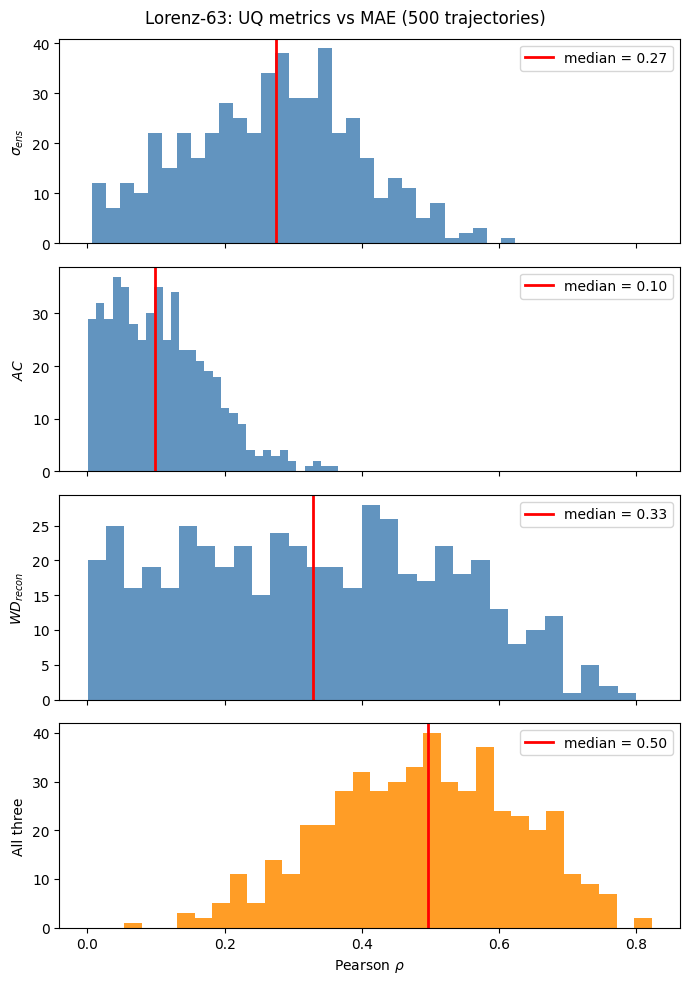

In [95]:
fig, axes = plt.subplots(4, 1, figsize=(7, 10), sharex=True)

for ax, rho, label, color in zip(
    axes,
    [rho_var, rho_ac, rho_wd, rho_all],
    [r'$\sigma_{ens}$', r'$AC$', r'$WD_{recon}$', 'All three'],
    ['steelblue', 'steelblue', 'steelblue', 'darkorange'],
):
    ax.hist(rho, bins=30, color=color, alpha=0.85)
    med = np.median(rho)
    ax.axvline(med, color='red', lw=2, label=f'median = {med:.2f}')
    ax.set_ylabel(label)
    ax.legend()

axes[-1].set_xlabel(r'Pearson $\rho$')
fig.suptitle('Lorenz-63: UQ metrics vs MAE (500 trajectories)', fontsize=12)
plt.tight_layout()
plt.show()

In [97]:
model = LinearRegression().fit(all_variance[1].reshape(-1, 1), all_mae_pertraj[1])
y_pred = model.predict(all_variance[1].reshape(-1, 1))

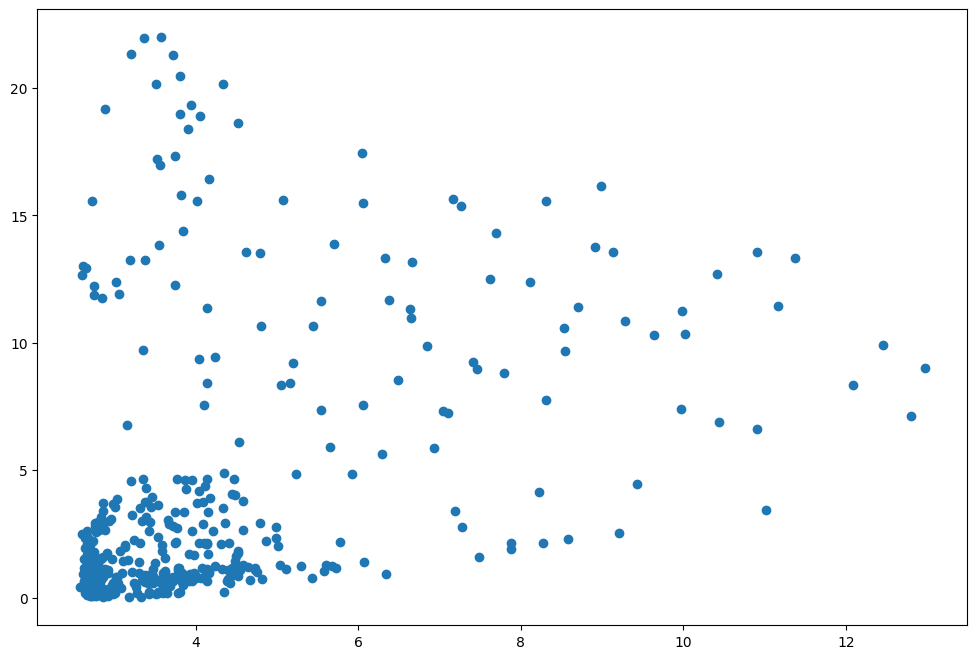

In [99]:
plt.figure(figsize=(12,8))
plt.scatter(y_pred,all_mae_pertraj[1])